# Notebook 02b: Kernels as Amplitudes — A Quantum-Inspired View

**Part 2b of the GRL Field Series** — *the complex-valued companion to 02 and 02a.*

---

## Why this notebook exists

Notebooks 02 and 02a worked exclusively with **real-valued** kernels — they gave "similarity" scores in $\mathbb{R}$. This is enough for most of classical ML, but it forecloses one thing you might actually want:

> **Interference.** If two experiences contribute to the field with opposite "phase", they should be able to *cancel each other out*. Real-valued kernels can't express that — positive weights add, negative weights add in a signed way, but there is no notion of relative phase between kernel contributions.

Physicists solved this problem a long time ago by going from probabilities to **amplitudes** (complex numbers whose modulus-squared is a probability). The same machinery transfers to RKHSs: allow $k: \mathcal{X}\times\mathcal{X} \to \mathbb{C}$ and you get a **complex RKHS** in which kernel values are amplitude overlaps and field superpositions can interfere.

This notebook is not about claiming the brain is quantum. It is about **borrowing a mathematical structure** — complex Hilbert spaces and amplitude-squared readouts — that turns out to be useful whenever your particles carry more than scalar magnitude (e.g., a temporal phase, a context tag, a direction).

## Learning objectives

1. Define a **complex-valued kernel** and state the PSD condition over $\mathbb{C}$.
2. Read $k(x, x')$ as an **amplitude overlap** $\langle \phi(x), \phi(x')\rangle_{\mathcal{H}}$ between complex feature representations.
3. Build a field $Q^+(z) = \sum_i w_i\, k(z_i, z)$ with complex weights $w_i \in \mathbb{C}$ and see constructive / destructive **interference** directly.
4. Use **phase** to encode temporal or contextual information, and read back probabilities via $|Q^+|^2$.
5. Know when complex kernels earn their keep and when they do not.

## Prerequisites

- Notebooks 02 and 02a (recommended)
- Comfort with complex numbers (modulus, phase, $e^{i\theta}$)
- No quantum mechanics required (but everything we do has a direct QM analogue)

## Time

~30–40 minutes.

## Companion material

A more formal treatment — complex RKHS axioms, Bochner for complex-valued functions, full reconciliation with `docs/GRL0/quantum_inspired/03-complex-rkhs.md` — lives in [docs/02b_amplitudes_and_complex_rkhs.md](docs/02b_amplitudes_and_complex_rkhs.md).


In [1]:
# Setup
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 5)
rng = np.random.default_rng(seed=7)
%matplotlib inline
print('ready')

ready


---
## Part 1: What Real-Valued Kernels Cannot Express

Consider two particles at positions $z_1, z_2$ with real weights $w_1, w_2$. The field

$$Q^+(z) = w_1 k(z_1, z) + w_2 k(z_2, z)$$

is an ordinary linear combination. Changing the *sign* of $w_2$ flips it from "attractive" to "repulsive." That is one bit of phase information.

But what if we wanted to express:

- "these two experiences are *about the same time*, reinforcing each other";
- "these two experiences happened in *different contexts*, and when querying the current context one should be emphasized while the other muted";
- "this action and its reverse action should cancel out on paths where they both fire"?

Each of those needs *more than one bit* of phase. That is exactly what complex numbers $w = |w|\, e^{i\theta}$ give you — a full circle of phase for free.

In classical RL we patch this by adding extra features (context vectors, time stamps, step counts) and training a larger model. In a complex RKHS, the *kernel itself* carries the phase structure, and field superposition picks up interference as a free consequence.


---
## Part 2: Complex Kernels — The Formal Setup

A **complex kernel** is a function

$$k: \mathcal{X} \times \mathcal{X} \to \mathbb{C}$$

satisfying:

1. **Conjugate (Hermitian) symmetry:** $\; k(x, x') = \overline{k(x', x)} \quad \forall x, x'.$
   (The real case $k(x, x') = k(x', x)$ is the special case where $k$ is already real.)
2. **Positive semi-definiteness over $\mathbb{C}$:** for every finite $\{x_i\}$ and every $\mathbf{c} \in \mathbb{C}^n$,
$$\sum_{i, j} \overline{c_i}\, c_j\, k(x_i, x_j) \;\ge\; 0.$$

The Gram matrix $K_{ij} = k(x_i, x_j)$ is then **Hermitian PSD**: $K = K^\dagger$ and $\mathbf{c}^\dagger K \mathbf{c} \ge 0$ for all $\mathbf{c} \in \mathbb{C}^n$.

### Moore–Aronszajn, the complex version

Every Hermitian PSD kernel arises as an inner product in a complex Hilbert space:

$$k(x, x') = \langle \phi(x), \phi(x') \rangle_{\mathcal{H}} = \phi(x)^\dagger \phi(x'),$$

where the feature map $\phi: \mathcal{X} \to \mathcal{H}$ now lands in a **complex** Hilbert space $\mathcal{H}$.

### A minimal non-trivial example

A useful building block is the **complex exponential kernel** on $\mathbb{R}$:

$$k(x, x') = \exp\!\big(i\,\omega\,(x - x')\big) = \cos(\omega(x-x')) + i\,\sin(\omega(x-x')).$$

This is Hermitian ($k(x', x) = \overline{k(x, x')}$), PSD (it's the "tight" stationary kernel from Bochner's theorem), and carries phase information: a shift $x \to x + \delta$ multiplies $\phi(x)$ by a global phase $e^{i\omega\delta}$.

We'll combine this with an RBF envelope to get a **damped oscillatory kernel**:

$$k_{\text{osc}}(x, x') \;=\; \exp\!\Big(-\tfrac{(x-x')^2}{2\ell^2}\Big) \cdot \exp\!\big(i\,\omega\,(x-x')\big).$$

The modulus $|k_{\text{osc}}|$ is just the RBF (the "similarity" part). The phase encodes directional / temporal structure via $\omega$.


In [2]:
# Demo 2.1: Build a damped oscillatory kernel and check its Gram matrix is Hermitian PSD.

def rbf_envelope(X, Y, lengthscale):
    X = np.atleast_2d(X); Y = np.atleast_2d(Y)
    sq = np.sum(X**2, axis=1)[:, None] + np.sum(Y**2, axis=1)[None, :] - 2 * X @ Y.T
    return np.exp(-sq / (2 * lengthscale**2))

def k_osc(X, Y, lengthscale=1.0, omega=3.0):
    '''Complex damped-oscillatory kernel on R.

    Hermitian: k(y, x) = conj(k(x, y)).  PSD: product of a real PSD kernel
    (RBF) and a Hermitian PSD kernel (e^{i omega (x - y)}); the elementwise
    (Hadamard) product of two PSD kernels is PSD (Schur product theorem).'''
    X = np.atleast_2d(X); Y = np.atleast_2d(Y)
    diff = X[:, None, :] - Y[None, :, :]   # shape (n, m, 1)
    diff = diff.squeeze(-1)
    envelope = rbf_envelope(X, Y, lengthscale)
    phase    = np.exp(1j * omega * diff)
    return envelope * phase

X_osc = np.linspace(-2, 2, 12).reshape(-1, 1)
K = k_osc(X_osc, X_osc, lengthscale=1.0, omega=3.0)

# Hermitian check: K = K^dagger (conjugate transpose).
herm_err = np.max(np.abs(K - K.conj().T))
print(f"Hermitian check:  max |K - K^dagger| = {herm_err:.2e}")

# PSD over C: eigenvalues of a Hermitian matrix are real; eigh handles this.
# We pass the complex Hermitian matrix directly; eigh returns real eigenvalues.
eigvals = la.eigh(K, eigvals_only=True)
print(f"Eigenvalues of K: min = {eigvals.min():.3e}, max = {eigvals.max():.3e}")
print(f"Hermitian PSD?    {herm_err < 1e-12 and eigvals.min() > -1e-10}")

Hermitian check:  max |K - K^dagger| = 0.00e+00
Eigenvalues of K: min = 8.014e-09, max = 5.876e+00
Hermitian PSD?    True


### What does it look like?

$k_{\text{osc}}(0, x')$ is a complex function of $x'$. Plot the modulus, the phase, and the real / imaginary parts side by side. The modulus is the familiar "similarity bump," but now wrapped with phase.


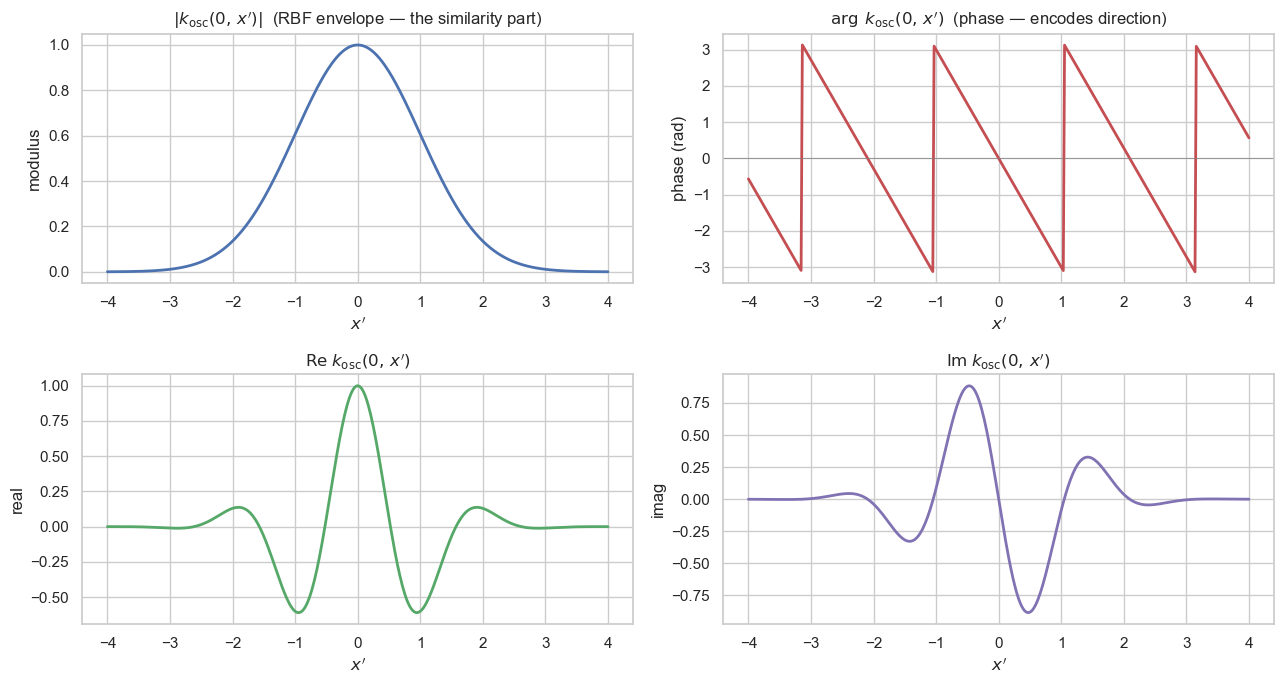

The MODULUS behaves like an ordinary RBF (a localized similarity bump).
The PHASE winds linearly with x' — this is the 'extra' information that
a real-valued kernel cannot carry.


In [3]:
# Demo 2.2: Visualize k_osc(0, x') as a function of x'.
x_prime = np.linspace(-4, 4, 400).reshape(-1, 1)
x0      = np.array([[0.0]])

kvals = k_osc(x0, x_prime, lengthscale=1.0, omega=3.0).ravel()

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
x_flat = x_prime.ravel()

axes[0, 0].plot(x_flat, np.abs(kvals), color='C0', lw=2)
axes[0, 0].set_title(r"$|k_{\mathrm{osc}}(0,\, x')|$  (RBF envelope — the similarity part)")
axes[0, 0].set_xlabel(r"$x'$"); axes[0, 0].set_ylabel('modulus')

axes[0, 1].plot(x_flat, np.angle(kvals), color='C3', lw=2)
axes[0, 1].set_title(r"$\arg\; k_{\mathrm{osc}}(0,\, x')$  (phase — encodes direction)")
axes[0, 1].set_xlabel(r"$x'$"); axes[0, 1].set_ylabel('phase (rad)')
axes[0, 1].axhline(0, color='gray', lw=0.5)

axes[1, 0].plot(x_flat, np.real(kvals), color='C2', lw=2)
axes[1, 0].set_title(r"$\mathrm{Re}\; k_{\mathrm{osc}}(0,\, x')$")
axes[1, 0].set_xlabel(r"$x'$"); axes[1, 0].set_ylabel('real')

axes[1, 1].plot(x_flat, np.imag(kvals), color='C4', lw=2)
axes[1, 1].set_title(r"$\mathrm{Im}\; k_{\mathrm{osc}}(0,\, x')$")
axes[1, 1].set_xlabel(r"$x'$"); axes[1, 1].set_ylabel('imag')

plt.tight_layout(); plt.show()
print("The MODULUS behaves like an ordinary RBF (a localized similarity bump).")
print("The PHASE winds linearly with x' — this is the 'extra' information that")
print("a real-valued kernel cannot carry.")

---
## Part 3: Interference — The Payoff

This is the whole reason for going complex. Put two particles at $z_1 = -1$ and $z_2 = +1$ with complex weights $w_1 = 1$ and $w_2 = e^{i\Delta}$. Form

$$Q^+(z) \;=\; w_1\, k_{\text{osc}}(z_1, z) + w_2\, k_{\text{osc}}(z_2, z).$$

Read out the probability density via the **amplitude-squared (Born-like) rule**:

$$\rho(z) \;=\; \frac{|Q^+(z)|^2}{\int |Q^+|^2}.$$

As we sweep the relative phase $\Delta$ from $0$ to $\pi$, watch $\rho$ transition continuously from **constructive interference** (big central bump) to **destructive interference** (central suppression, two side peaks) — the same pattern you would see in a two-slit experiment.

Real-valued weights cannot do this: with $w_1 = 1$ and $w_2 = -1$ you just get a signed two-bump structure; there is no smooth sweep in between.


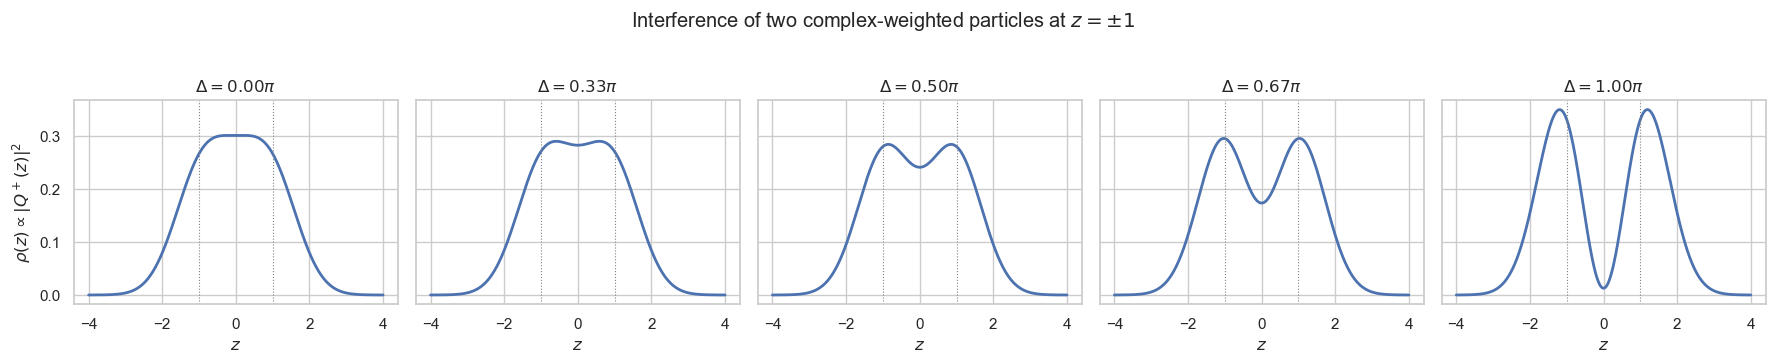

Delta = 0      -> constructive:   big central lobe (particles reinforce)
Delta = pi/2   -> mixed:          asymmetric profile
Delta = pi     -> destructive:    central suppression, two side peaks

Classical real-weighted kernels CANNOT produce this continuous sweep.


In [4]:
# Demo 3.1: Sweep relative phase from 0 to pi and watch interference emerge.

z = np.linspace(-4, 4, 600).reshape(-1, 1)
z1 = np.array([[-1.0]])
z2 = np.array([[ 1.0]])

deltas = [0.0, np.pi/3, np.pi/2, 2*np.pi/3, np.pi]

fig, axes = plt.subplots(1, len(deltas), figsize=(18, 3.5), sharey=True)

for ax, delta in zip(axes, deltas):
    w1 = 1.0 + 0.0j
    w2 = np.exp(1j * delta)
    Q_plus = (w1 * k_osc(z1, z, lengthscale=1.0, omega=3.0).ravel()
              + w2 * k_osc(z2, z, lengthscale=1.0, omega=3.0).ravel())
    rho = np.abs(Q_plus)**2
    rho = rho / np.trapezoid(rho, z.ravel())
    ax.plot(z.ravel(), rho, color='C0', lw=2)
    ax.axvline(-1, color='gray', lw=0.8, ls=':'); ax.axvline(1, color='gray', lw=0.8, ls=':')
    ax.set_title(rf'$\Delta = {delta/np.pi:.2f}\pi$')
    ax.set_xlabel('$z$')
axes[0].set_ylabel(r'$\rho(z) \propto |Q^+(z)|^2$')
plt.suptitle(r'Interference of two complex-weighted particles at $z = \pm 1$', y=1.03)
plt.tight_layout(); plt.show()

print("Delta = 0      -> constructive:   big central lobe (particles reinforce)")
print("Delta = pi/2   -> mixed:          asymmetric profile")
print("Delta = pi     -> destructive:    central suppression, two side peaks")
print("\nClassical real-weighted kernels CANNOT produce this continuous sweep.")

---
## Part 4: Phase as Context or Time

What is phase *for*? In this section we sketch one concrete use: **encoding a non-spatial coordinate as phase** on the kernel.

Suppose each particle has a spatial position $z_i \in \mathbb{R}$ and a context tag $t_i \in [0, T]$ (a timestamp, a task index, a reward phase, ...). Define a **context-conditioned kernel**:

$$k_{\text{ctx}}(z, t;\; z', t') \;=\; \underbrace{\exp\!\Big(-\tfrac{(z - z')^2}{2\ell_z^2}\Big)}_{\text{spatial similarity}} \cdot \underbrace{\exp\!\big(i\, \omega\, (t - t')\big)}_{\text{phase from context difference}}.$$

When we query the field at $(z, t)$, particles whose context matches exactly ($t_i = t$) contribute with phase $0$, particles from a far context contribute with a phase that averages out. The Born-like readout $|Q^+|^2$ then naturally emphasizes context-matching experience and suppresses context-mismatched experience **without an explicit mask**.

This is a toy example, but it illustrates a real pattern: **phase is a free carrier for information you don't want in the modulus**. In the GRL extensions track, this is one way to imagine operator actions acquiring a compositional phase structure; see `docs/GRL0/quantum_inspired/05-concept-projections-and-measurements.md`.


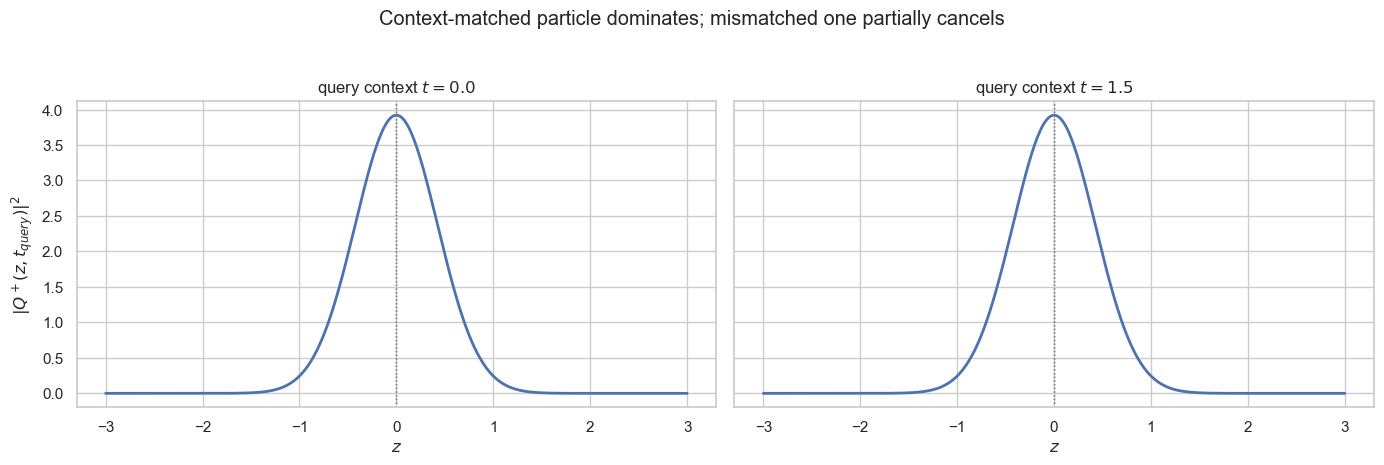

Both particles sit at z=0 with equal spatial weight. But when the query
context matches one of them, the phase alignment makes that particle
coherent; the other contributes with a phase that reduces |Q+|^2.


In [5]:
# Demo 4.1: Context as phase. Two particles at the same z=0, different contexts t=0 and t=T/2.
# When we query at current context t=0, only the matching particle contributes coherently.

def k_ctx(Z1, T1, Z2, T2, l_z=1.0, omega=4.0):
    '''k((z, t), (z', t')) = RBF(z, z') * e^{i omega (t - t')}.

    All inputs are 1D arrays: Z1, T1 of length n; Z2, T2 of length m.
    Returns a (n, m) complex kernel matrix.'''
    Z1, T1, Z2, T2 = map(np.asarray, (Z1, T1, Z2, T2))
    dz = Z1[:, None] - Z2[None, :]
    dt = T1[:, None] - T2[None, :]
    return np.exp(-dz**2 / (2 * l_z**2)) * np.exp(1j * omega * dt)

# Two particles at the same spatial position but different context tags.
z_particles = np.array([0.0, 0.0])
t_particles = np.array([0.0, 1.5])
w = np.array([1.0 + 0j, 1.0 + 0j])

# Query grid: z in [-3, 3], at two different query contexts
z_query = np.linspace(-3, 3, 400)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

for ax, t_query_val in zip(axes, [0.0, 1.5]):
    t_query = np.full_like(z_query, t_query_val)
    K_qp = k_ctx(z_query, t_query, z_particles, t_particles, l_z=0.6, omega=4.0)
    Q_plus = K_qp @ w
    ax.plot(z_query, np.abs(Q_plus)**2, lw=2, color='C0')
    for zp, tp in zip(z_particles, t_particles):
        ax.axvline(zp, color='gray', ls=':', lw=1)
    ax.set_title(rf'query context $t = {t_query_val}$')
    ax.set_xlabel('$z$')
axes[0].set_ylabel(r'$|Q^+(z, t_{query})|^2$')
plt.suptitle('Context-matched particle dominates; mismatched one partially cancels', y=1.03)
plt.tight_layout(); plt.show()
print("Both particles sit at z=0 with equal spatial weight. But when the query")
print("context matches one of them, the phase alignment makes that particle")
print("coherent; the other contributes with a phase that reduces |Q+|^2.")

---
## Part 5: Born-like Readout

In quantum mechanics, $|\psi(x)|^2$ gives a probability density when $\psi$ is a normalized wavefunction. The GRL analogue:

$$\rho(z) \;=\; \frac{|Q^+(z)|^2}{\int |Q^+(z')|^2\, dz'}.$$

A few things worth noting:

- **$Q^+$ itself is not a probability** — it is complex-valued and can have negative real part, oscillatory behaviour, etc. The probability interpretation is only obtained after the $|\cdot|^2$ step and normalization.
- **Phase is lost in the readout** — $|Q^+|^2$ discards the phase of $Q^+$. But phase is what drove the interference pattern that we now read out as a density. So phase matters *during* superposition but is invisible *after* readout. (This is exactly the QM picture.)
- **Compositionality lives at the amplitude level.** If we want to compose two fields — e.g., a value field and a context field — we add the *amplitudes*, then square; not square and add. This preserves interference.

The GRL-extensions track (see `docs/GRL0/quantum_inspired/01a-wavefunction-interpretation.md`) explores how far this analogy can be pushed in a control setting.


---
## Part 6: When Do Complex Kernels Earn Their Keep?

Borrowing a Hilbert-space structure from QM is not free. A few honest caveats before you apply this to anything:

- **If nothing in your problem has phase, don't use a complex kernel.** Adding imaginary parts "just in case" doubles the representational cost without helping — the imaginary part will train to zero (or noise) and you gain nothing.
- **Phase has to come from *somewhere* real in the data.** Examples:
  - Time / ordering → phase proportional to time step
  - Context / task identity → phase as a learned embedding argument
  - Rotational symmetry → angle as phase
  - Operator composition (Paper A direction) → phase as operator argument
- **Interpretation of derivatives / gradients changes.** Complex gradients follow the Wirtinger calculus; straight PyTorch autograd of $|\cdot|^2$ is fine, but be careful with manual derivations.
- **Numerical libraries are fine with complex tensors, but optimizers aren't always.** Use complex-safe primitives (Adam works on real-and-imaginary parts separately; some other optimizers don't).

### Where this plugs into GRL

Speculative but worth naming:

- **Track A (GRL0).** Complex kernels are an *optional* upgrade to the reinforcement field. The existing chapters (`docs/GRL0/quantum_inspired/01–08`) already set up the machinery; this notebook is the hands-on companion.
- **Track B (GRL extensions).** Operator composition is a natural source of phase: composing $\hat{O}_{\theta_1} \circ \hat{O}_{\theta_2}$ is a non-commutative product, and its group/algebraic structure often carries a phase (think Heisenberg-type relations). This is speculative but points to where Paper B / C might benefit from complex-valued field machinery.

Don't use this for Paper A as it stands; use it when the domain provides phase.


---
## Summary

**Complex kernel.** $k: \mathcal{X}\times\mathcal{X} \to \mathbb{C}$, Hermitian-symmetric and PSD over $\mathbb{C}$. Every such kernel is an inner product in a complex feature space: $k(x, x') = \phi(x)^\dagger \phi(x')$.

**Amplitude overlap.** The "similarity" reading of $k$ generalizes to an amplitude-overlap reading. Magnitude is similarity; phase is additional structure.

**Interference.** Complex-weighted superpositions of kernel sections produce constructive / destructive interference in $|Q^+|^2$. Real kernels cannot express this continuously.

**Born-like readout.** Probabilities come from $|Q^+|^2$ after normalization. Phase is lost in the readout, but it shaped the distribution during superposition.

**When to use.** Only when the domain naturally supplies phase (time, context, operator composition). Don't complexify for its own sake.

### Connections

- **Back:** Notebook 02 (informal kernel intro) and 02a (real-valued formal RKHS).
- **Up:** `docs/GRL0/quantum_inspired/` chapters — especially 02 (amplitudes), 03 (complex RKHS), 05 (concept projections) — for the full formal treatment and GRL-specific claims.
- **Forward:** Notebook 03 (reinforcement field demo) will stay real-valued; the complex extension is optional depth.

### Supplementary material

Complex Moore–Aronszajn, Schur product theorem (used to show our damped-oscillatory kernel is PSD), and the reconciliation with the quantum-inspired chapters live in [docs/02b_amplitudes_and_complex_rkhs.md](docs/02b_amplitudes_and_complex_rkhs.md).
